# Adverse selection in the Avellaneda–Stoikov model

The paper's model (replicated in `01_replication.ipynb`) has no adverse selection: fills are independent of price moves, so the market maker's inventory PnL has mean zero and all of its expected profit comes from spread capture. This notebook adds the simplest form of informed order flow, extends the exact dynamic-programming solution to it, and asks two questions: how much does adverse selection cost the paper's strategies, and how should the market maker respond?

## TL;DR

- **Model.** Every fill moves the mid permanently by ε in the direction of the trade: a buyer lifting the ask pushes the mid up by ε, a seller hitting the bid pushes it down by ε. ε = 0 is the paper's model. The simulator and the exact dynamic program both handle ε > 0, and the dynamic program still matches brute-force enumeration of every path to 1e−9.
- **An exact accounting identity.** On every path, the PnL caused by these moves is −(ε/2)·(N₁ + q_T²), where N₁ is the number of steps with exactly one fill. Each fill costs ε/2, terminal inventory costs (ε/2)·q_T², and the inventory path in between does not matter.
- **Inventory control halves the cost.** The symmetric strategy's inventory is a martingale, so E[q_T²] = E[N₁] and it pays a full ε per fill as dt → 0 (0.77ε at the paper's dt = 0.005, where steps with fills on both sides are free). The A-S strategy keeps q_T small and pays about 0.55ε (0.43ε at dt = 0.005). At γ = 0.1 A-S overtakes the symmetric strategy on mean profit once ε > 0.12 (16% of the half-spread), so with adverse selection the inventory skew improves the mean as well as the risk.
- **The textbook adjustment over-reacts.** Frozen-inventory indifference prices say: widen each side by ε and skew by an extra −qε. Evaluated exactly, this is worse than not adjusting at all (certainty equivalent 48.6 vs 52.4 at ε = 0.25). The best adjustment on a grid is much smaller and gains little, because A-S already controls the only inventory term that is penalised, terminal inventory.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from mmsim import Params, AvellanedaStoikov, AdjustedAS, Symmetric, simulate, draw_randomness, exact_moments, mean_se

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 200)

P = Params()               # paper parameters; impact = 0, i.e. no adverse selection
GAMMAS = [0.1, 0.01, 1.0]  # Tables 1, 2, 3 of the published version
EPS_REF = 0.25             # reference adverse move: about a third of the average half-spread at gamma = 0.1

def strategies(gamma, p=P):
    return {"inventory": AvellanedaStoikov(gamma), "symmetric": Symmetric.matching(gamma, p)}

## 1. Model

Everything is as in the paper (and notebook 01) except for one term in the mid-price dynamics. At each step the market maker quotes; the ask fills with probability $A e^{-k\delta^a}dt$ and the bid with probability $A e^{-k\delta^b}dt$; then the mid moves by

$$\Delta S_i = \pm\sigma\sqrt{dt} + \varepsilon\,(\text{sold}_i - \text{bought}_i).$$

A filled ask means a buyer arrived, and the mid moves up by ε; a filled bid moves it down by ε. The direction of a fill therefore predicts the next price move, which is what adverse selection means: the counterparty knew something. This is the single-dealer view of Glosten & Milgrom (1985), in which every trade goes through the market maker and moves its estimate of value. Mathematically it is linear permanent price impact of the market maker's fills.

In the code this is one parameter, `Params(impact=ε)`:

- `simulate` adds the jump to the mid after each step's fills and reports the PnL it causes as `impact_pnl` (a part of `inventory_pnl`);
- `exact_moments` folds the jump into the step's edge, $e = \text{sold}\cdot\delta^a + \text{bought}\cdot\delta^b + q'\,\varepsilon\,(\text{sold} - \text{bought})$, because the jump is known once the fill outcome is known. The rest of the recursion is unchanged and still exact.

Both extensions are covered by the unit tests: the dynamic program is compared with brute-force enumeration of every path of a 6-step model with ε = 0.3 (agreement to 1e−9) and with 40000-path Monte Carlo at the paper's parameters.

One consequence is worth stating up front. Quotes are set relative to the mid, so fill probabilities depend only on the quote distances, never on the mid level. Under common random numbers the fills and the inventory path are therefore **identical** with and without adverse selection; only the mid path, and with it the PnL, changes.

## 2. An exact accounting identity

Write $\Delta q_i = \text{bought}_i - \text{sold}_i$. The jump is $-\varepsilon\,\Delta q_i$ and the PnL it causes is $-\varepsilon\sum_i q_{i+1}\Delta q_i$. Since $q_{i+1} = q_i + \Delta q_i$ and $q_{i+1}^2 - q_i^2 = 2q_i\Delta q_i + \Delta q_i^2$, a telescoping sum with $q_0 = 0$ gives

$$\sum_{i} q_{i+1}\Delta q_i = \sum_i \big(q_i\Delta q_i + \Delta q_i^2\big) = \frac{q_T^2 + \sum_i \Delta q_i^2}{2}.$$

A step with exactly one fill has $\Delta q_i^2 = 1$; a step with no fill, or with fills on both sides, has $\Delta q_i^2 = 0$. So on every path

$$\text{impact PnL} = -\frac{\varepsilon}{2}\big(N_1 + q_T^2\big),\qquad N_1 = \#\{\text{steps with exactly one fill}\}.$$

Nothing in the derivation depends on the strategy. Read as a market maker:

- **every fill costs ε/2.** A round trip (buy, then sell back) pushes the mid down and back up and costs ε in total;
- **terminal inventory costs (ε/2)·q_T².** A position that is never unwound was built while the mid kept moving against it;
- **intermediate inventory is free.** The gains and losses from marking a position to the moving mid cancel once the position is unwound.

The check below confirms the identity on simulated paths (it is also a unit test).

In [2]:
eps, n = EPS_REF, 2000
p = P.with_(impact=eps)
rows = []
for name, strat in strategies(0.1).items():
    r = simulate(strat, p, n_paths=n, seed=1, log_trades=True)
    fills = np.bincount(r.trades["path"] * p.n_steps + r.trades["step"], minlength=n * p.n_steps).reshape(n, p.n_steps)
    n1 = (fills == 1).sum(axis=1)                     # steps with exactly one fill
    rows.append({"strategy": name, "mean impact PnL": r.impact_pnl.mean(), "mean N1": n1.mean(),
                 "mean q_T^2": (r.q**2).mean(),
                 "max |impact PnL + (eps/2)(N1 + q_T^2)|": np.abs(r.impact_pnl + eps / 2 * (n1 + r.q**2)).max()})
pd.DataFrame(rows).set_index("strategy")

,mean impact PnL,mean N1,mean q_T^2,max |impact PnL + (eps/2)(N1 + q_T^2)|
strategy,,,,
inventory,-10.54325,75.6090,8.7370,0.0
symmetric,-17.85675,70.3755,72.4785,0.0


## 3. What adverse selection costs the paper's strategies

Because the fills do not depend on ε, each strategy's expected PnL is **exactly linear** in ε:

$$\mathbb{E}[\text{PnL}](\varepsilon) = \mathbb{E}[\text{PnL}](0) - c\,\varepsilon,\qquad c = \tfrac12\,\mathbb{E}\big[N_1 + q_T^2\big].$$

The table gives c from the dynamic program, its two parts, the cost per fill, and the ε at which expected profit falls to zero. For the symmetric strategy the fills do not depend on inventory, so its inventory is a martingale and $\mathbb{E}[q_T^2] = \mathbb{E}[N_1]$: it pays exactly ε per single-fill step. The A-S strategy keeps $\mathbb{E}[q_T^2]$ small.

In [3]:
rows = []
for g in GAMMAS:
    for name, strat in strategies(g).items():
        e0, e1 = exact_moments(strat, P), exact_moments(strat, P.with_(impact=EPS_REF))
        c = (e0["mean_pnl"] - e1["mean_pnl"]) / EPS_REF      # exact, since mean PnL is linear in eps
        qT2 = e0["std_q"]**2 + e0["mean_q"]**2
        rows.append({"gamma": g, "strategy": name, "profit at eps = 0": e0["mean_pnl"], "fills": e0["mean_trades"],
                     "E[N1]": 2 * c - qT2, "E[q_T^2]": qT2, "cost c": c, "cost per fill (x eps)": c / e0["mean_trades"],
                     "break-even eps": e0["mean_pnl"] / c})
cost = pd.DataFrame(rows).set_index(["gamma", "strategy"])

for g in GAMMAS:
    inv, sym = cost.loc[(g, "inventory")], cost.loc[(g, "symmetric")]
    cross = (sym["profit at eps = 0"] - inv["profit at eps = 0"]) / (sym["cost c"] - inv["cost c"])
    if 0 < cross < min(inv["break-even eps"], sym["break-even eps"]):
        print(f"gamma = {g}: A-S has the higher mean profit for eps > {cross:.3f}")
    else:
        print(f"gamma = {g}: the symmetric strategy keeps the higher mean profit while both are profitable")
cost.round(3)

gamma = 0.1: A-S has the higher mean profit for eps > 0.117
gamma = 0.01: A-S has the higher mean profit for eps > 0.011
gamma = 1.0: the symmetric strategy keeps the higher mean profit while both are profitable


profit at eps = 0    fills   E[N1]  E[q_T^2]  cost c  cost per fill (x eps)  break-even eps
gamma strategy                                                                                              
0.10  inventory             64.893   96.963  75.733     8.566  42.150                  0.435           1.540
      symmetric             68.223   91.465  70.551    70.551  70.551                  0.771           0.967
0.01  inventory             68.400  102.206  76.293    27.171  51.732                  0.506           1.322
      symmetric             68.666  101.802  75.893    75.893  75.893                  0.745           0.905
1.00  inventory             31.455   56.059  49.153     2.694  25.924                  0.462           1.213
      symmetric             43.685   28.819  26.743    26.743  26.743                  0.928           1.634

- At γ = 0.1 the symmetric strategy pays 0.77ε per fill and A-S only 0.43ε. A-S starts 3.3 behind on mean profit and catches up once ε > 0.12, about 16% of the half-spread. From there on the inventory skew improves both mean and risk.
- At γ = 0.01 the two strategies start almost level, so A-S is ahead for any ε above 0.011.
- At γ = 1 the comparison goes the other way. The symmetric strategy's average spread is so wide that it trades only half as often as A-S, so its total cost is about the same and it keeps its higher mean.
- The costs per fill are below their continuous-time values because a step in which both sides fill moves the mid up and back down and costs nothing. Section 5 shows the limit dt → 0: ε per fill for the symmetric strategy and about 0.55ε for A-S.

The figure shows the mean and standard deviation of terminal PnL as ε grows (γ = 0.1). Lines are exact; dots are Monte Carlo with common random numbers (20000 paths).

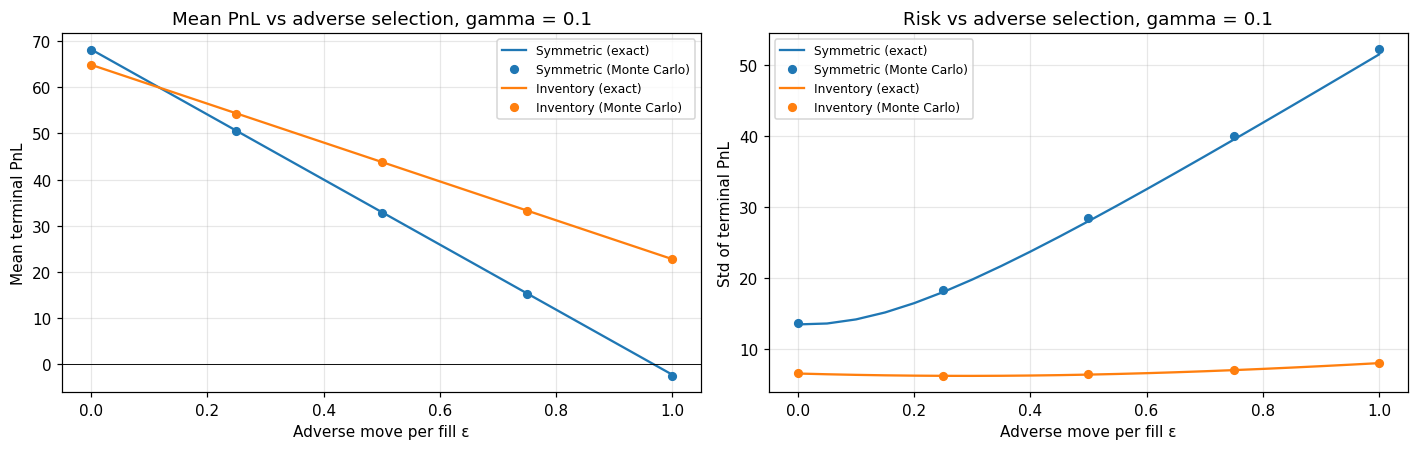

In [4]:
g = 0.1
eps_grid = np.linspace(0, 1, 21)
exact = {name: [exact_moments(strat, P.with_(impact=e)) for e in eps_grid] for name, strat in strategies(g).items()}
mc_eps = [0.0, 0.25, 0.5, 0.75, 1.0]
rnd = draw_randomness(P, 20000, seed=2)
mc = {name: [simulate(strat, P.with_(impact=e), 20000, randomness=rnd) for e in mc_eps] for name, strat in strategies(g).items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
for name, c in [("symmetric", "tab:blue"), ("inventory", "tab:orange")]:
    ax1.plot(eps_grid, [e["mean_pnl"] for e in exact[name]], color=c, label=f"{name.capitalize()} (exact)")
    ax1.plot(mc_eps, [r.pnl.mean() for r in mc[name]], "o", color=c, ms=5, label=f"{name.capitalize()} (Monte Carlo)")
    ax2.plot(eps_grid, [e["std_pnl"] for e in exact[name]], color=c, label=f"{name.capitalize()} (exact)")
    ax2.plot(mc_eps, [r.pnl.std() for r in mc[name]], "o", color=c, ms=5, label=f"{name.capitalize()} (Monte Carlo)")
ax1.axhline(0, color="k", lw=0.6)
ax1.set_xlabel("Adverse move per fill ε"); ax1.set_ylabel("Mean terminal PnL")
ax1.set_title(f"Mean PnL vs adverse selection, gamma = {g}"); ax1.legend(fontsize=8)
ax2.set_xlabel("Adverse move per fill ε"); ax2.set_ylabel("Std of terminal PnL")
ax2.set_title(f"Risk vs adverse selection, gamma = {g}"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

The symmetric strategy's risk also grows quickly with ε, because the (ε/2)·q_T² term is largest exactly when its unbounded inventory has wandered far. The standard deviation of A-S barely moves.

### 3.1 Where the loss shows up

Notebook 01 predicted that adverse selection would make the mean of inventory PnL negative. Splitting inventory PnL into its diffusion part and its impact part confirms this (ε = 0.25, γ = 0.1, the 20000 Monte Carlo paths above):

In [5]:
k = mc_eps.index(EPS_REF)
rows = []
for name in ["inventory", "symmetric"]:
    base, res = mc[name][0], mc[name][k]
    diffusion = res.inventory_pnl - res.impact_pnl
    rows.append({"strategy": name, "total PnL": res.pnl.mean(), "total PnL at eps = 0": base.pnl.mean(),
                 "spread capture": res.spread_pnl.mean(), "spread capture at eps = 0": base.spread_pnl.mean(),
                 "diffusion PnL": diffusion.mean(), "diffusion PnL SE": mean_se(diffusion)[1],
                 "impact PnL": res.impact_pnl.mean(), "impact PnL (exact)": -EPS_REF * cost.loc[(g, name), "cost c"]})
pd.DataFrame(rows).set_index("strategy").round(2)

,total PnL,total PnL at eps = 0,spread capture,spread capture at eps = 0,diffusion PnL,diffusion PnL SE,impact PnL,impact PnL (exact)
strategy,,,,,,,,
inventory,54.28,64.79,64.82,64.82,-0.03,0.02,-10.51,-10.54
symmetric,50.48,68.18,68.18,68.18,-0.00,0.09,-17.69,-17.64


Spread capture is exactly the same as without adverse selection (the fills are the same), the diffusion part of inventory PnL still has mean zero, and the whole loss sits in the impact part, which matches its exact value.

## 4. How should the market maker respond?

### 4.1 The frozen-inventory adjustment

Repeat the paper's indifference argument (notebook 01, appendix A.1) with the jump included. A market maker who sells one share at $r^a$ and then holds $q - 1$ shares until T sees the mid move to $s + \varepsilon$, so indifference requires

$$r^a = s + \varepsilon\,(1 - q) + \tfrac12\gamma\sigma^2(T-t)(1 - 2q),\qquad r^b = s - \varepsilon\,(1 + q) - \tfrac12\gamma\sigma^2(T-t)(1 + 2q).$$

Compared with the paper, each reservation price moves out by ε and both move by an extra $-q\varepsilon$: **widen each side by ε and skew harder by ε per unit of inventory.** This is `AdjustedAS.frozen_inventory(gamma, eps)`. To see which half matters, the table also evaluates each half on its own (`AdjustedAS(gamma, widen=eps)` and `AdjustedAS(gamma, skew=eps)`), and a symmetric strategy widened by ε on each side. All numbers are exact. CE is the CARA certainty equivalent at γ = 0.1, the objective A-S is designed to maximise.

In [6]:
def responses(g, eps, p=P):
    sym = Symmetric.matching(g, p)
    return {"plain A-S": AvellanedaStoikov(g), "widen only": AdjustedAS(g, widen=eps), "skew only": AdjustedAS(g, skew=eps),
            "frozen-inventory (both)": AdjustedAS.frozen_inventory(g, eps),
            "symmetric": sym, "symmetric, widened": Symmetric(sym.spread + 2 * eps)}

rows = []
for eps in [0.1, EPS_REF, 0.5]:
    for name, strat in responses(g, eps).items():
        ex = exact_moments(strat, P.with_(impact=eps), gamma_ce=g)
        rows.append({"eps": eps, "strategy": name, "mean": ex["mean_pnl"], "std": ex["std_pnl"], "CE": ex["ce"],
                     "fills": ex["mean_trades"], "std q_T": ex["std_q"]})
pd.DataFrame(rows).set_index(["eps", "strategy"]).round(2)

mean    std       CE   fills  std q_T
eps  strategy                                                       
0.10 plain A-S                60.68   6.36    58.69   96.96     2.93
     widen only               60.32   6.77    58.06   83.59     2.89
     skew only                58.78   5.88    57.08   99.98     1.50
     frozen-inventory (both)  58.90   6.32    56.94   86.29     1.52
     symmetric                61.17  14.16  -541.43   91.47     8.40
     symmetric, widened       60.27  13.64  -384.72   78.73     7.95
0.25 plain A-S                54.36   6.22    52.42   96.96     2.93
     widen only               53.08   7.02    50.65   66.85     2.81
     skew only                48.74   5.27    47.38  104.68     0.99
     frozen-inventory (both)  50.45   6.14    48.61   72.67     1.04
     symmetric                50.59  18.01 -3173.59   91.47     8.40
     symmetric, widened       49.36  15.19 -2561.64   62.86     7.28
0.50 plain A-S                43.82   6.39    41.60   96.96     2.93
     widen only               41.45   7.21    38.83   46.00     2.65
     skew only                28.98   4.76    27.89  112.91     0.73
     frozen-inventory (both)  38.25   5.71    36.67   54.79     0.77
     symmetric                32.95  27.98 -8180.00   91.47     8.40
     symmetric, widened       34.56  17.09 -6870.83   43.21     6.21

- **The full frozen-inventory adjustment is worse than doing nothing** at every ε. At ε = 0.25 its CE is 48.6, against 52.4 for plain A-S.
- **Both halves hurt when applied in full, and the extra skew hurts much more.** "Skew only" has the smallest standard deviation, but it gives up so much spread capture that its CE falls far below plain A-S.
- The symmetric strategies are far behind on CE: their unbounded inventory makes the (ε/2)·q_T² term, and with it the CARA utility, explode.

The identity of Section 2 explains why the textbook argument over-reacts. It prices each fill as if the new position were held until T, so every unit of inventory is charged the full adverse move. In fact only terminal inventory is charged, and A-S already keeps it small: $\mathbb{E}[q_T^2] \approx 8.6$ at γ = 0.1, so at ε = 0.25 no amount of extra skew can save more than about $0.125 \times 8.6 \approx 1.1$. Pushing inventory towards zero harder throughout the day buys very little and costs spread.

### 4.2 The best adjustment in this family

The dynamic program is exact and fast, so we can search the (widen, skew) plane for the pair with the highest CE. The heat maps show the CE gain over plain A-S.

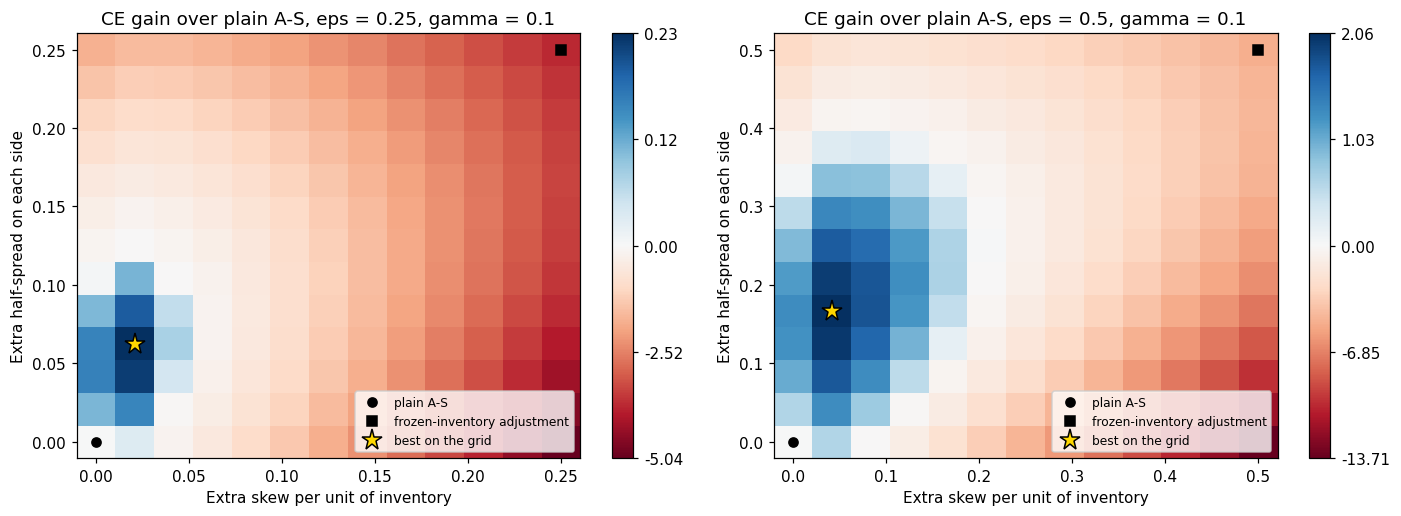

,best widen,best skew,CE gain vs plain A-S,CE gain of frozen-inventory adjustment
eps,,,,
0.25,0.062,0.021,0.231,-3.810
0.50,0.167,0.042,2.060,-4.928


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
best = []
for ax, eps in zip(axes, [EPS_REF, 0.5]):
    p = P.with_(impact=eps)
    W = np.linspace(0, eps, 13)          # extra half-spread on each side
    K = np.linspace(0, eps, 13)          # extra skew per unit of inventory
    ce = np.array([[exact_moments(AdjustedAS(g, widen=w, skew=kk), p, gamma_ce=g)["ce"] for kk in K] for w in W])
    gain = ce - ce[0, 0]
    i, j = np.unravel_index(gain.argmax(), gain.shape)
    best.append({"eps": eps, "best widen": W[i], "best skew": K[j], "CE gain vs plain A-S": gain[i, j],
                 "CE gain of frozen-inventory adjustment": gain[-1, -1]})
    im = ax.pcolormesh(K, W, gain, shading="nearest", cmap="RdBu",
                       norm=TwoSlopeNorm(vmin=gain.min(), vcenter=0, vmax=max(gain.max(), 1e-9)))
    ax.plot(0, 0, "ko", ms=6, label="plain A-S")
    ax.plot(eps, eps, "ks", ms=6, label="frozen-inventory adjustment")
    ax.plot(K[j], W[i], "*", color="gold", mec="k", ms=14, label="best on the grid")
    ax.set_xlabel("Extra skew per unit of inventory"); ax.set_ylabel("Extra half-spread on each side")
    ax.set_title(f"CE gain over plain A-S, eps = {eps}, gamma = {g}"); ax.legend(fontsize=8, loc="lower right")
    ax.grid(False)
    fig.colorbar(im, ax=ax, ticks=[gain.min(), gain.min() / 2, 0, gain.max() / 2, gain.max()], format="%.2f")
plt.tight_layout(); plt.show()
pd.DataFrame(best).set_index("eps").round(3)

- The best pair is small. At ε = 0.25 it widens each side by about 0.06 and adds a skew of about 0.02, for a CE gain of only 0.23. At ε = 0.5 it is about (0.17, 0.04), with a gain of about 2.1. The frozen-inventory adjustment loses 3.8 and 4.9 instead.
- The widening that helps is close to what a risk-neutral market maker would add. If each fill costs ε/2, the mean-maximising distance moves from $1/k$ to $1/k + \varepsilon/2$. The A-S half-spread at γ = 0.1 is already about 0.08 wider than $1/k$ on average, which leaves about ε/2 − 0.08 to add: 0.05 at ε = 0.25 and 0.17 at ε = 0.5, against 0.06 and 0.17 on the grid (grid steps 0.021 and 0.042).
- So against this form of adverse selection, plain A-S is already close to the best that simple adjustments can do, and the textbook adjustment should not be applied as is.

## 5. Discretisation check

In the discrete model a step in which both sides fill moves the mid up and back down, so it costs nothing; at dt = 0.005 such steps account for about a fifth of all fills. The cost per fill therefore rises as dt shrinks. For the symmetric strategy the cost per fill is exactly $(1-\lambda)\,\varepsilon$, where λ is its per-step fill probability, so it tends to ε. A-S tends to about 0.55ε.

In [8]:
rows = []
for dt in [0.005, 0.0025, 0.001, 0.0005]:
    pdt = P.with_(dt=dt)
    row = {"dt": dt}
    for name, strat in strategies(g, pdt).items():
        e0, e1 = exact_moments(strat, pdt), exact_moments(strat, pdt.with_(impact=EPS_REF))
        row[f"{name}: cost per fill (x eps)"] = (e0["mean_pnl"] - e1["mean_pnl"]) / EPS_REF / e0["mean_trades"]
    lam = P.A * np.exp(-P.k * Symmetric.matching(g, pdt).spread / 2) * dt
    row["symmetric: 1 - lambda"] = 1 - lam
    rows.append(row)
pd.DataFrame(rows).set_index("dt").round(3)

,inventory: cost per fill (x eps),symmetric: cost per fill (x eps),symmetric: 1 - lambda
dt,,,
0.0050,0.435,0.771,0.771
0.0025,0.498,0.886,0.886
0.0010,0.535,0.954,0.954
0.0005,0.547,0.977,0.977


## 6. Summary and limitations

**Findings:**
1. With fill-triggered adverse moves of size ε, the impact PnL is exactly −(ε/2)(N₁ + q_T²) on every path: each fill costs ε/2, and only terminal inventory is penalised.
2. The symmetric strategy pays a full ε per fill in the dt → 0 limit; A-S pays about 0.55ε, because it keeps terminal inventory small. At γ = 0.1, A-S has the higher mean profit as soon as ε > 0.12.
3. The adjustment implied by frozen-inventory indifference prices (widen by ε, skew by an extra qε) is worse than no adjustment. The best small adjustment widens by roughly ε/2 minus the risk premium already in the A-S spread and barely changes the skew.

**Limitations (and directions for extension):**
- Only the market maker's own fills move the mid (the single-dealer view). In models where every market order moves the mid whether or not it fills the market maker, as in the adverse-selection models of Cartea, Jaimungal & Penalva (2015, ch. 10), the price-moving flow is independent of the market maker's inventory. Each fill then costs about ε whatever the strategy, and inventory control no longer reduces the cost per fill.
- ε is constant and the information is fully permanent: no decay, no stochastic toxicity, no dependence on order size.
- Terminal inventory is still liquidated at the (moved) mid at no cost.
- Section 4.2 searches a two-parameter family around A-S. The truly optimal quotes could be computed by turning the dynamic program from evaluating a given strategy into optimising the quotes at each (q, t), which is the natural next step.

**References:**
- Glosten, L. R. & Milgrom, P. R. (1985). Bid, ask and transaction prices in a specialist market with heterogeneously informed traders. *Journal of Financial Economics* 14(1), 71–100.
- Cartea, Á., Jaimungal, S. & Penalva, J. (2015). *Algorithmic and High-Frequency Trading*. Cambridge University Press.